# 手撕Actor-Critic

In [1]:
import gymnasium as gym
import numpy as np
from collections import deque
import random
import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions import Categorical

In [2]:
%%html
<img src="img/ActorCritic.png", width=800,height=400>

## Actor-Critic的计算公式
$$
\nabla_\theta J(\theta)=\mathbb{E}_{\tau\sim p(\tau;\theta)}\left[\sum_{t=0}^{T-1}\nabla_\theta\log\pi_\theta(a_t|s_t)A(s_t,a_t)\right]\approx\mathbb{E}_{\tau\sim p(\tau;\theta)}\left[\sum_{t=0}^{T-1}\nabla_\theta\log\pi_\theta(a_t|s_t)\underbrace{(r+\gamma V(s_{t+1})-V(s_t))}_{\text{TD误整(TD Error)}}\right]
$$

# 定义策略网络

In [3]:
class Policy(nn.Module):
    """
    实现Actor和Critic网络，2个头，共享底座
    """
    def __init__(self, in_states, h1_nodes, out_actions):
        super(Policy, self).__init__()
        self.fc = nn.Linear(in_states, h1_nodes)

        # Actor输出
        self.action_head = nn.Linear(h1_nodes, out_actions)

        # Critic输出
        self.value_head = nn.Linear(h1_nodes, 1)

    def forward(self, x):

        x = F.relu(self.fc(x))

        # actor: 计算输出动作概率
        action_prob = F.softmax(self.action_head(x), dim=-1)

        # critic: 评估状态价值
        state_value = self.value_head(x)

        return action_prob, state_value

# 训练和预测代码

In [5]:
class ActorCritic():
    
    # 超参数
    learning_rate = 0.03            # 学习率
    gamma = 0.99                    # 折扣因子  
    hidden_size = 128               # 网络隐藏层维度

    # 训练阶段
    def train(self, episodes):
        # 创建环境
        env = gym.make('CartPole-v1')
        env.reset(seed=543)
        torch.manual_seed(543)

        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n

        # 创建策略网络
        policy = Policy(in_states=num_states, h1_nodes=self.hidden_size, out_actions=num_actions)

        # 优化器 
        self.optimizer = torch.optim.Adam(policy.parameters(), lr=self.learning_rate)

        # 收集每一个episode的reward
        rewards_per_episode = []
        
        for episode in range(episodes):
            state = env.reset()[0]  # 初始化环境
            done = False 

            rewards = []
            log_probs = []
            state_values = []
            
            while not done:
                # 选择 action
                action, log_prob, state_value = self.select_action(policy, state)
                # action = self.select_action(policy, state)

                # 执行动作
                state, reward, terminated, truncated,_ = env.step(action)
                done = terminated or truncated

                # 记录reward, 动作概率, 状态价值
                rewards.append(reward)
                # policy.rewards.append(reward)
                log_probs.append(log_prob)
                state_values.append(state_value)
            

            # 更新回合reward
            rewards_per_episode.append(sum(rewards))
            
            # 优化模型
            actor_loss, critic_loss = self.optimize(policy, rewards, log_probs, state_values)
            
            # 打印 reward
            if(episode + 1) % 20 == 0:
                print(f"episode {episode + 1}, actor loss: {actor_loss:.2f}, critic_loss: {critic_loss:.2f}, gain: {np.mean(rewards_per_episode[-100:]):.2f}")

        # 关闭环境
        env.close()

        # 保存训练好的策略网络
        torch.save(policy.state_dict(), "saved/cartpole_actor_critic.pt")

        return rewards_per_episode
        

    def select_action(self, model, state):
        state = torch.from_numpy(state).float()
        probs, state_value = model(state)
    
        # 构造一个softmax分布，便于采样
        categorical_dist = Categorical(probs)
    
        # 采样一个action，这里按照概率来采样
        action = categorical_dist.sample()
        
        # 拿到对应动作的对数概率
        log_prob = categorical_dist.log_prob(action)
    
        return action.item(), log_prob, state_value


    def optimize(self, model, rewards, log_probs, state_values):
        """优化actor网络和critic网络"""
        
        R = 0 # 累计折扣收益
        eps = 1e-7 # 防止除0
        policy_losses = [] # policy loss
        value_losses = [] # value loss
        discounted_rewards = [] # 每一个timestep的折扣收益
    
        for r in rewards[::-1]: #倒着计算
            R = r + self.gamma * R
            discounted_rewards.insert(0, R)

        # reward 做一下归一化，方便加速收敛
        discounted_rewards = torch.tensor(discounted_rewards)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + eps)
    
        for log_prob, value, R in zip(log_probs, state_values, discounted_rewards):
            advantage = R - value.item()
    
            # 计算actor的loss
            policy_losses.append(-log_prob * advantage)
    
            # 计算critic loss: L1 smooth loss
            value_losses.append(F.smooth_l1_loss(value, torch.tensor([R])))
    
        # 清空梯度
        self.optimizer.zero_grad()
    
        # 多目标优化：policy_losses 和 value_losses 求和
        actor_loss = torch.stack(policy_losses).sum() 
        critic_loss = torch.stack(value_losses).sum()
        loss = actor_loss + critic_loss
    
        # perform backprop
        loss.backward()
        self.optimizer.step()
        
        return actor_loss.item(), critic_loss.item()
    
    # 测试阶段
    def test(self, episodes):
        # 初始化环境
        env = gym.make('CartPole-v1', render_mode='human')
        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n

        # 加载训练好的模型
        policy = Policy(in_states=num_states, h1_nodes=self.hidden_size, out_actions=num_actions) 
        policy.load_state_dict(torch.load("saved/cartpole_actor_critic.pt"))
        policy.eval()    # 预测模式

        for i in range(episodes):
            state = env.reset()[0]          
            done = False
            while(not done):   
                with torch.no_grad():
                    state = torch.tensor(state).unsqueeze(0)
                    action = policy(state)[0].argmax().item()
                # 执行动作
                state, reward, terminated, truncated, _  = env.step(action)
                done = terminated or truncated

        env.close()

# 开始训练

In [6]:
n_episode = 300
actor_critic = ActorCritic()
rewards_per_episode = actor_critic.train(n_episode)

episode 20, actor loss: 22.26, critic_loss: 17.60, gain: 40.80
episode 40, actor loss: 2.14, critic_loss: 2.29, gain: 34.30
episode 60, actor loss: 9.14, critic_loss: 5.40, gain: 62.57
episode 80, actor loss: 63.40, critic_loss: 69.09, gain: 89.75
episode 100, actor loss: -11.33, critic_loss: 26.25, gain: 95.44
episode 120, actor loss: 0.75, critic_loss: 20.66, gain: 124.69
episode 140, actor loss: -5.67, critic_loss: 1.27, gain: 149.44
episode 160, actor loss: -26.95, critic_loss: 23.11, gain: 150.58
episode 180, actor loss: 18.73, critic_loss: 7.33, gain: 153.93
episode 200, actor loss: 163.75, critic_loss: 237.27, gain: 177.25
episode 220, actor loss: 34.08, critic_loss: 137.64, gain: 194.98
episode 240, actor loss: -119.34, critic_loss: 171.90, gain: 260.44
episode 260, actor loss: 58.06, critic_loss: 22.79, gain: 304.96
episode 280, actor loss: 30.69, critic_loss: 13.49, gain: 357.20
episode 300, actor loss: -12.95, critic_loss: 49.43, gain: 408.30


# 可视化reward曲线

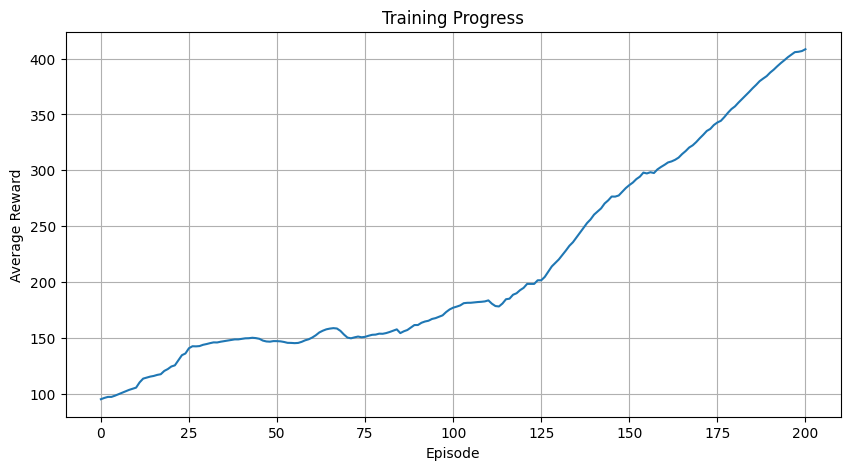

In [7]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

# 测试环境

In [7]:
actor_critic.test(1)